###  Defected Graphene
In this tutorial we take a look graphene containing a defect. We have previously treated graphene using tight-binding, and here we go a bit further and treat the electronic structure of the system using DFT. We will also be needing to use the decoupling of the $z$-parity states in graphene to significantly truncate the Hamiltonian of the system. 

In [1]:
import matplotlib.pyplot as plt
import sisl
import numpy as np
from TimedependentTransport.TimedependentTransport import TD_Transport
from TimedependentTransport.TimedependentTransport import AdaptiveRK4  as RK4

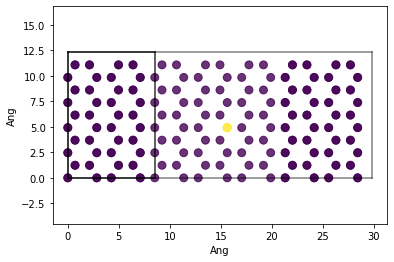

Directory called EM already exists! Remove it? (y/reuse/n)
 set struct
done
No atoms overlapping within 0.3 Å!
self.pos is reduced coordinates, self.pos_real_space is actual coordinates!

Directory called EP already exists! Remove it? (y/reuse/n)
 set struct
done
No atoms overlapping within 0.3 Å!
self.pos is reduced coordinates, self.pos_real_space is actual coordinates!

Directory called Device already exists! Remove it? (y/reuse/n)
 set struct
done
No atoms overlapping within 0.3 Å!
self.pos is reduced coordinates, self.pos_real_space is actual coordinates!

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39], [100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139]]
Running Siesta electrode calculation in Directory: EM!



In [ ]:
tx       = 3
ty       = 5

g        =  sisl.geom.graphene(orthogonal = True).tile(ty,1)
geom_dev =  g.tile(tx+4,0)#.add_vacuum(10,1)
geom_em  =  g.tile(2,0)
geom_ep  =  g.tile(2,0).move((tx+2) * g.cell[0,:])
geom_dev.atoms[71] = sisl.Atom('N')
sisl.plot(geom_dev); plt.axis('equal');
sisl.plot(geom_em) ; sisl.plot(geom_ep)
plt.show()

eta = 1e-1
line = np.vstack([np.linspace(-6,6,95) + 1j * eta]*2)


G = TD_Transport([geom_em, geom_ep], geom_dev, kT_i = [0.025, 0.025])

G.Make_Contour(line, 35, pole_mode = 'JieHu2011')

G.Electrodes( semi_infs = ['-a1', '+a1'] , kp = [[50,10,1],[50,10,1]])
G.make_device(k = [1,10,1], k_tbtrans = [1,10,1])

G.run_electrodes()
G.run_device()

In [ ]:
G.read_data()
plt.show()
plt.plot(G.tbtT[G.sampling_idx[0]], label = 'TBtrans Transmission')
plt.xlabel('Energy')
plt.legend()

In [ ]:
from Block_matrices.Block_matrices import Blocksparse2Numpy as b2n
G.Inspect_Transmission(1,0)
assert 1 == 0

g1      = G.Nonortho_Gammas[0]
g2      = G.Nonortho_Gammas[1]
L, iL   = G.Lowdin
G_NO    = G.Nonortho_iG


igno = b2n(G_NO, G._Slices)
g1 = b2n(g1, G._Slices)
g2 = b2n(g2, G._Slices)
gno = np.linalg.inv(igno)
Tr = np.trace(g1@gno@g2@(gno.transpose(0,1,3,2).conj()), axis1 = 2, axis2 = 3)
T01 = (Tr*G.tbtwkpt[:,np.newaxis]).sum(axis = 0)
plt.plot(T01[G.sampling_idx[0]])


In [ ]:
G.reset_all_fits()
def run_mini(its):
    G.Fit(fact = 1.0,  NumL = 15,
              min_method='L-BFGS-B',
              ebounds = (-15, 15), 
              wbounds = (0.01, 20.0), 
              gbounds = (None, None),
              tol = -1, 
              options = {'disp':True,
                         'maxiter':its, 
                         'gtol':1e-5, 
                         #'ftol':1e-10, 
                         #'iprint':1
                         },
              fit_real_part = False,
              specific_bounds = None, 
              alpha_PO = 0.01,
              cons = '')


In [ ]:
run_mini(1000)

In [ ]:
G.Inspect_transmission_from_SE_fit(eta = 1e-1)

In [ ]:
G.diagonalise()

In [ ]:
G.Inspect_SE_lorentzian_fit(0, 0,0,4,4, Emin = -8, Emax = 8)